# PS-S6E6 CatBoost GPU Model v3

This notebook trains a single 5-fold CatBoost model for the Playground Series S6E6 stellar classification competition. It reproduces local experiment `CAT2-035`, the best completed CatBoost experiment from my `exp-cat2` search, with local 5-fold CV `0.96887081`.

The model is intentionally different from target-encoded tree models: it gives CatBoost many native categorical views of the astronomical numeric columns, including quantile bins, rounded numeric artifacts, color/magnitude bins, sky-position bins, and compact hashed category interactions. The original SDSS dataset is appended to each fold's training pool with a small sample weight (`0.06`), after reconstructing the competition-only `spectral_type` and `galaxy_population` columns from simple color thresholds.

The validation score is honest: the same fixed seed-42 stratified 5-fold split is used, validation rows are never appended to their own fold training pool, and there is no post-processing. The notebook saves exactly three artifacts:

- `train_oof/cat-3_oof.npy`
- `test_preds/cat-3_test_preds.npy`
- `subs/cat-3_submission.csv`

The feature generation uses RAPIDS cuDF/cuPy, then CatBoost trains on GPU. To make this practical on Kaggle's T4 16GB GPU, categorical features are stored as `int32` codes, temporary GPU memory is freed before model fitting, CatBoost writes no snapshots, and test predictions are made in batches.

## Environment

In [1]:
import os

# Kaggle normally exposes two T4 as visible GPU 0,1. Change this locally if needed.
os.environ.setdefault('CUDA_VISIBLE_DEVICES', '0,1')
os.environ.setdefault('TOKENIZERS_PARALLELISM', 'false')

# Keep CPU helper libraries from using too many threads while CatBoost owns the GPU.
os.environ.setdefault('OMP_NUM_THREADS', '4')
os.environ.setdefault('MKL_NUM_THREADS', '4')
os.environ.setdefault('OPENBLAS_NUM_THREADS', '4')
os.environ.setdefault('NUMEXPR_NUM_THREADS', '4')

'4'

In [2]:
import gc
import glob
import random
import time
import warnings
from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd

import cupy as cp
import cudf
import catboost as cb
from catboost import CatBoostClassifier, Pool
from IPython.display import display
from sklearn.metrics import balanced_accuracy_score, confusion_matrix
from sklearn.model_selection import StratifiedKFold

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 160)
pd.set_option('display.width', 180)

T0 = time.perf_counter()

def log(msg):
    print(f'[{time.perf_counter() - T0:8.1f}s] {msg}', flush=True)

print('cuDF:', cudf.__version__)
print('CatBoost:', cb.__version__)

cuDF: 26.02.01
CatBoost: 1.2.10


## Configuration

In [3]:
MODEL_ID = 'cat-3'
SEED = 42
N_SPLITS = 5
TARGET = 'class'
ID_COL = 'id'

CLASSES = ['GALAXY', 'QSO', 'STAR']
CLASS_TO_INT = {c: i for i, c in enumerate(CLASSES)}
INT_TO_CLASS = {i: c for c, i in CLASS_TO_INT.items()}

RAW_NUM_COLS = ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift']
BANDS = ['u', 'g', 'r', 'i', 'z']
BASE_CATS = ['spectral_type', 'galaxy_population']
EPS = np.float32(1e-6)

# CAT2-035 settings.
ORIGINAL_WEIGHT = 0.06
ITERATIONS = 5000
EARLY_STOPPING_ROUNDS = 260
PREDICT_BATCH_SIZE = 80_000

OOF_PATH = Path('train_oof') / f'{MODEL_ID}_oof.npy'
PRED_PATH = Path('test_preds') / f'{MODEL_ID}_test_preds.npy'
SUB_PATH = Path('subs') / f'{MODEL_ID}_submission.csv'
for path in [OOF_PATH.parent, PRED_PATH.parent, SUB_PATH.parent]:
    path.mkdir(parents=True, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
cp.random.seed(SEED)

## Load Data

In [4]:
def find_competition_root():
    candidates = [
        Path('/kaggle/input/competitions/playground-series-s6e6'),
    ]
    candidates += [Path(p).parent for p in glob.glob('/kaggle/input/*/train.csv')]
    seen = []
    for root in candidates:
        if root not in seen:
            seen.append(root)
    for root in seen:
        if (root / 'train.csv').exists() and (root / 'test.csv').exists():
            return root
    raise FileNotFoundError('Could not find train.csv and test.csv. Add the competition data to notebook inputs.')


def find_original_path():
    candidates = [
        Path('/kaggle/input/datasets/fedesoriano/stellar-classification-dataset-sdss17/star_classification.csv'),
    ]
    candidates += [Path(p) for p in glob.glob('/kaggle/input/*/star_classification.csv')]
    seen = []
    for path in candidates:
        if path not in seen:
            seen.append(path)
    for path in seen:
        if path.exists():
            return path
    raise FileNotFoundError('Could not find star_classification.csv. Add the original SDSS dataset to notebook inputs.')


def clean_num(s):
    return cudf.to_numeric(s, errors='coerce').astype('float32')


def cat_key(s):
    return s.astype('str').fillna('__NA__')


def spectral_type_from_gr(g, r):
    return cudf.cut(
        r - g,
        [-np.inf, -1.0, -0.5, 0.0, np.inf],
        labels=['M', 'G/K', 'A/F', 'O/B'],
    ).astype('str')


def galaxy_population_from_ur(u, r):
    return cudf.cut(
        u - r,
        [-np.inf, 2.2, np.inf],
        labels=['Blue_Cloud', 'Red_Sequence'],
    ).astype('str')


def read_competition_csv(path, is_train):
    df = cudf.read_csv(str(path))
    for c in RAW_NUM_COLS:
        df[c] = clean_num(df[c])
    for c in BASE_CATS:
        df[c] = cat_key(df[c])
    if ID_COL in df.columns:
        df[ID_COL] = df[ID_COL].astype('int32')
    if is_train:
        df[TARGET] = df[TARGET].astype('str')
    return df


def read_original_csv(path):
    orig = cudf.read_csv(str(path))
    keep = cudf.DataFrame()
    keep[ID_COL] = cudf.Series((-1 - cp.arange(len(orig), dtype=cp.int32)))
    for c in RAW_NUM_COLS:
        keep[c] = clean_num(orig[c])
    keep['spectral_type'] = spectral_type_from_gr(keep['g'], keep['r'])
    keep['galaxy_population'] = galaxy_population_from_ur(keep['u'], keep['r'])
    keep[TARGET] = orig[TARGET].astype('str').str.upper()
    keep = keep[keep[TARGET].isin(CLASSES)].reset_index(drop=True)
    for c in BASE_CATS:
        keep[c] = cat_key(keep[c])
    return keep


DATA_ROOT = find_competition_root()
ORIG_PATH = find_original_path()

train = read_competition_csv(DATA_ROOT / 'train.csv', is_train=True)
test = read_competition_csv(DATA_ROOT / 'test.csv', is_train=False)
original = read_original_csv(ORIG_PATH)

sample_path = DATA_ROOT / 'sample_submission.csv'
sample = pd.read_csv(sample_path) if sample_path.exists() else None

y = train[TARGET].to_pandas().map(CLASS_TO_INT).astype('int8').to_numpy()
y_original = original[TARGET].to_pandas().map(CLASS_TO_INT).astype('int8').to_numpy()
test_ids = test[ID_COL].to_pandas().to_numpy() if ID_COL in test.columns else np.arange(len(test), dtype=np.int32)

print('competition root:', DATA_ROOT)
print('original dataset:', ORIG_PATH)
print('train/test/original:', train.shape, test.shape, original.shape)
print('target distribution:')
display(pd.Series(y).map(INT_TO_CLASS).value_counts(normalize=True).sort_index().to_frame('ratio'))

competition root: /kaggle/input/competitions/playground-series-s6e6
original dataset: /kaggle/input/datasets/fedesoriano/stellar-classification-dataset-sdss17/star_classification.csv
train/test/original: (577347, 12) (247435, 11) (100000, 12)
target distribution:


,ratio
GALAXY,0.653818
QSO,0.202899
STAR,0.143283


## GPU Feature Engineering

In [5]:
def to_cp(s, dtype=np.float32):
    return s.to_cupy(dtype=dtype, na_value=np.nan)


def add_series(gdf, name, values, dtype='float32'):
    gdf[name] = cudf.Series(cp.asarray(values).astype(dtype))


def finite_float(values):
    arr = cp.asarray(values, dtype=cp.float32)
    return cp.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0).astype(cp.float32)


def safe_div_gpu(a, b):
    aa = to_cp(a) if hasattr(a, 'to_cupy') else cp.asarray(a, dtype=cp.float32)
    bb = to_cp(b) if hasattr(b, 'to_cupy') else cp.asarray(b, dtype=cp.float32)
    return finite_float(aa / (bb + cp.float32(EPS)))


def cat_from_cp(gdf, name, values):
    arr = cp.asarray(values)
    if arr.dtype.kind == 'f':
        arr = cp.nan_to_num(arr, nan=-2147483648.0, posinf=2147483647.0, neginf=-2147483648.0)
    gdf[name] = cudf.Series(arr.astype(cp.int32))


def qbin_cat_gpu(gdf, source, bins, name):
    arr = to_cp(gdf[source])
    valid = cp.isfinite(arr)
    if int(valid.sum().get()) <= 1:
        cat_from_cp(gdf, name, cp.full(arr.shape, -1, dtype=cp.int32))
        return
    qs = cp.linspace(0, 1, bins + 1, dtype=cp.float32)[1:-1]
    edges = cp.quantile(arr[valid], qs)
    edges = cp.unique(edges[cp.isfinite(edges)])
    if len(edges) == 0:
        codes = cp.zeros(arr.shape, dtype=cp.int32)
    else:
        codes = cp.searchsorted(edges, arr, side='right').astype(cp.int32)
    codes = cp.where(valid, codes, cp.int32(-1))
    cat_from_cp(gdf, name, codes)


def floor_cat_gpu(gdf, source, name):
    arr = to_cp(gdf[source])
    cat_from_cp(gdf, name, cp.floor(cp.nan_to_num(arr, nan=-999999.0)))


def round_cat_gpu(gdf, source, decimals, name):
    arr = to_cp(gdf[source])
    scale = cp.float32(10 ** decimals)
    cat_from_cp(gdf, name, cp.rint(cp.nan_to_num(arr, nan=-999999.0) * scale))


def hash2(gdf, a, b, name):
    aa = gdf[a].to_cupy(dtype=np.int64, na_value=-1)
    bb = gdf[b].to_cupy(dtype=np.int64, na_value=-1)
    vals = ((aa + 1_000_003) * 1_000_003 + (bb + 9_176)) % 2_147_483_647
    cat_from_cp(gdf, name, vals)


def hash3(gdf, a, b, c, name):
    aa = gdf[a].to_cupy(dtype=np.int64, na_value=-1)
    bb = gdf[b].to_cupy(dtype=np.int64, na_value=-1)
    cc = gdf[c].to_cupy(dtype=np.int64, na_value=-1)
    vals = (((aa + 1_000_003) * 1_000_003 + (bb + 9_176)) * 1_000_003 + (cc + 17_191)) % 2_147_483_647
    cat_from_cp(gdf, name, vals)


def build_features_gpu(train_gdf, test_gdf, original_gdf):
    n_train = len(train_gdf)
    n_test = len(test_gdf)

    frames = [train_gdf.drop(columns=[TARGET]), test_gdf, original_gdf.drop(columns=[TARGET])]
    gdf = cudf.concat(frames, axis=0, ignore_index=True)
    del frames

    for c in RAW_NUM_COLS:
        gdf[c] = gdf[c].astype('float32')

    spec_map = {'M': 0, 'G/K': 1, 'A/F': 2, 'O/B': 3}
    pop_map = {'Blue_Cloud': 0, 'Red_Sequence': 1}
    gdf['spectral_type'] = gdf['spectral_type'].astype('str').map(spec_map).fillna(-1).astype('int32')
    gdf['galaxy_population'] = gdf['galaxy_population'].astype('str').map(pop_map).fillna(-1).astype('int32')

    cat_cols = ['spectral_type', 'galaxy_population']

    # Public-combo feature family: all optical color differences and absolute differences.
    for a, b in combinations(BANDS, 2):
        gdf[f'{a}_{b}'] = (gdf[a] - gdf[b]).astype('float32')
        gdf[f'{a}_{b}_abs'] = gdf[f'{a}_{b}'].abs().astype('float32')

    mags = cp.stack([to_cp(gdf[b]) for b in BANDS], axis=1)
    add_series(gdf, 'mag_mean', cp.nanmean(mags, axis=1))
    add_series(gdf, 'mag_std', cp.nanstd(mags, axis=1))
    add_series(gdf, 'mag_min', cp.nanmin(mags, axis=1))
    add_series(gdf, 'mag_max', cp.nanmax(mags, axis=1))
    gdf['mag_range'] = (gdf['mag_max'] - gdf['mag_min']).astype('float32')
    cat_from_cp(gdf, 'mag_argmin', cp.nanargmin(mags, axis=1))
    cat_from_cp(gdf, 'mag_argmax', cp.nanargmax(mags, axis=1))
    cat_cols += ['mag_argmin', 'mag_argmax']

    x = cp.arange(len(BANDS), dtype=cp.float32)
    x_center = x - x.mean()
    centered = mags - cp.nanmean(mags, axis=1)[:, None]
    add_series(gdf, 'mag_slope', centered.dot(x_center) / cp.sum(x_center ** 2))
    gdf['mag_curvature'] = (gdf['u'] - 2 * gdf['r'] + gdf['z']).astype('float32')
    gdf['blue_curvature'] = (gdf['u'] - 2 * gdf['g'] + gdf['r']).astype('float32')
    gdf['red_curvature'] = (gdf['r'] - 2 * gdf['i'] + gdf['z']).astype('float32')

    redshift = to_cp(gdf['redshift'])
    gdf['redshift_abs'] = gdf['redshift'].abs().astype('float32')
    add_series(gdf, 'redshift_log1p_abs', cp.log1p(cp.abs(redshift)))
    gdf['redshift_sq'] = (gdf['redshift'] ** 2).astype('float32')
    add_series(gdf, 'redshift_cbrt', cp.cbrt(redshift))
    cat_from_cp(gdf, 'redshift_is_neg', redshift < 0)
    cat_from_cp(gdf, 'redshift_lt_002', redshift < 0.02)
    cat_from_cp(gdf, 'redshift_gt_07', redshift > 0.7)
    cat_cols += ['redshift_is_neg', 'redshift_lt_002', 'redshift_gt_07']

    add_series(gdf, 'g_over_redshift', safe_div_gpu(gdf['g'], cp.abs(redshift)))
    add_series(gdf, 'i_over_redshift', safe_div_gpu(gdf['i'], cp.abs(redshift)))
    add_series(gdf, 'z_over_redshift', safe_div_gpu(gdf['z'], cp.abs(redshift)))
    add_series(gdf, 'z_over_g', safe_div_gpu(gdf['z'], gdf['g']))
    add_series(gdf, 'z2_over_g2', safe_div_gpu(to_cp(gdf['z']) ** 2, to_cp(gdf['g']) ** 2))
    add_series(gdf, 'log_z_over_log_g', safe_div_gpu(cp.log1p(cp.abs(to_cp(gdf['z']))), cp.log1p(cp.abs(to_cp(gdf['g'])))))
    add_series(gdf, 'sqrt_z_over_sqrt_g', safe_div_gpu(cp.sqrt(cp.abs(to_cp(gdf['z']))), cp.sqrt(cp.abs(to_cp(gdf['g'])))))
    for b in BANDS:
        gdf[f'redshift_x_{b}'] = (gdf['redshift'] * gdf[b]).astype('float32')

    add_series(gdf, 'ug_gr_ratio', safe_div_gpu(gdf['u_g'], gdf['g_r']))
    add_series(gdf, 'gr_ri_ratio', safe_div_gpu(gdf['g_r'], gdf['r_i']))
    add_series(gdf, 'ri_iz_ratio', safe_div_gpu(gdf['r_i'], gdf['i_z']))
    color_mat = cp.stack([to_cp(gdf[c]) for c in ['u_g', 'g_r', 'r_i', 'i_z']], axis=1)
    add_series(gdf, 'color_mean', cp.nanmean(color_mat, axis=1))
    add_series(gdf, 'color_std', cp.nanstd(color_mat, axis=1))
    add_series(gdf, 'color_abs_sum', cp.nansum(cp.abs(color_mat), axis=1))

    gr = cp.clip(to_cp(gdf['g_r']), -5, 5)
    ur = cp.clip(to_cp(gdf['u_r']), -5, 8)
    add_series(gdf, 'color_temp_gr_proxy', finite_float(4600.0 * ((1.0 / (0.92 * gr + 1.7)) + (1.0 / (0.92 * gr + 0.62)))))
    gdf['uv_excess_proxy'] = (gdf['u_g'] - (0.75 * gdf['g_r'] + 0.18)).astype('float32')
    add_series(gdf, 'red_sequence_score_proxy', ur - 2.2)

    alpha_rad = to_cp(gdf['alpha']) * cp.float32(cp.pi / 180.0)
    delta_rad = to_cp(gdf['delta']) * cp.float32(cp.pi / 180.0)
    add_series(gdf, 'alpha_sin', cp.sin(alpha_rad))
    add_series(gdf, 'alpha_cos', cp.cos(alpha_rad))
    add_series(gdf, 'delta_sin', cp.sin(delta_rad))
    add_series(gdf, 'delta_cos', cp.cos(delta_rad))
    add_series(gdf, 'sky_x', cp.cos(delta_rad) * cp.cos(alpha_rad))
    add_series(gdf, 'sky_y', cp.cos(delta_rad) * cp.sin(alpha_rad))
    add_series(gdf, 'sky_z', cp.sin(delta_rad))

    fluxes = []
    for b in BANDS:
        clipped = cp.clip(to_cp(gdf[b]), -30, 30)
        flux = cp.power(cp.float32(10.0), cp.float32(-0.4) * clipped).astype(cp.float32)
        add_series(gdf, f'flux_{b}', flux)
        add_series(gdf, f'log_flux_{b}', cp.log1p(flux))
        fluxes.append(flux)
    fv = cp.stack(fluxes, axis=1)
    add_series(gdf, 'flux_mean', cp.nanmean(fv, axis=1))
    add_series(gdf, 'flux_std', cp.nanstd(fv, axis=1))
    add_series(gdf, 'flux_range', cp.nanmax(fv, axis=1) - cp.nanmin(fv, axis=1))
    for a, b in [('u', 'g'), ('g', 'r'), ('r', 'i'), ('i', 'z'), ('u', 'r'), ('r', 'z')]:
        color = cp.clip(to_cp(gdf[a]) - to_cp(gdf[b]), -20, 20)
        add_series(gdf, f'flux_ratio_{a}_{b}', cp.exp(cp.float32(-0.921034) * color))

    rg = to_cp(gdf['r']) - to_cp(gdf['g'])
    spec_calc = cp.where(rg <= -1.0, 0, cp.where(rg <= -0.5, 1, cp.where(rg <= 0.0, 2, 3)))
    pop_calc = cp.where((to_cp(gdf['u']) - to_cp(gdf['r'])) <= 2.2, 0, 1)
    cat_from_cp(gdf, 'spectral_type_calc', spec_calc)
    cat_from_cp(gdf, 'galaxy_population_calc', pop_calc)
    cat_from_cp(gdf, 'spectral_x_pop', gdf['spectral_type'].to_cupy(dtype=np.int32, na_value=-1) * 10 + gdf['galaxy_population'].to_cupy(dtype=np.int32, na_value=-1))
    cat_from_cp(gdf, 'spectral_calc_x_pop_calc', spec_calc * 10 + pop_calc)
    cat_cols += ['spectral_type_calc', 'galaxy_population_calc', 'spectral_x_pop', 'spectral_calc_x_pop_calc']

    for c in RAW_NUM_COLS:
        name = f'{c}_floor_cat'
        floor_cat_gpu(gdf, c, name)
        cat_cols.append(name)

    q_specs = {c: [32, 100, 500] for c in RAW_NUM_COLS}
    for c in ['u_g', 'g_r', 'r_i', 'i_z', 'u_r', 'r_z', 'mag_range', 'mag_std']:
        q_specs.setdefault(c, [64])
    for c, bins_list in q_specs.items():
        for bins in bins_list:
            name = f'{c}_q{bins}_cat'
            qbin_cat_gpu(gdf, c, bins, name)
            cat_cols.append(name)

    round_specs = {
        'alpha': 1, 'delta': 1, 'u': 2, 'g': 2, 'r': 2, 'i': 2, 'z': 2,
        'redshift': 4, 'u_g': 3, 'g_r': 3, 'r_i': 3, 'i_z': 3,
        'u_r': 3, 'r_z': 3, 'mag_range': 3,
    }
    for c, dec in round_specs.items():
        name = f'{c}_round{dec}_cat'
        round_cat_gpu(gdf, c, dec, name)
        cat_cols.append(name)

    for c in RAW_NUM_COLS:
        vals = cp.abs(to_cp(gdf[c]))
        ints = cp.floor(cp.nan_to_num(vals, nan=0.0)).astype(cp.int64)
        frac = cp.floor((vals - cp.floor(vals)) * 20).astype(cp.int32)
        dec = cp.floor((vals - cp.floor(vals)) * 1000).astype(cp.int32)
        for suffix, arr in [('mod10', ints % 10), ('mod100', ints % 100), ('frac20', frac), ('decimal1000', dec)]:
            name = f'{c}_{suffix}_cat'
            cat_from_cp(gdf, name, arr)
            cat_cols.append(name)

    manual_combos = [
        ('alpha_floor_cat', 'delta_floor_cat'),
        ('u_floor_cat', 'z_floor_cat'),
        ('spectral_type', 'galaxy_population'),
        ('spectral_x_pop', 'redshift_q64_cat'),
        ('u_r_q64_cat', 'redshift_q64_cat'),
        ('g_r_q64_cat', 'mag_range_q64_cat'),
        ('alpha_q100_cat', 'delta_q100_cat'),
        ('u_q100_cat', 'z_q100_cat'),
        ('spectral_x_pop', 'redshift_q100_cat'),
    ]
    for a, b in manual_combos:
        if a in gdf.columns and b in gdf.columns:
            name = f'COMBO_{a}__{b}'
            hash2(gdf, a, b, name)
            cat_cols.append(name)

    combo_bases = [
        'spectral_type', 'galaxy_population', 'spectral_x_pop',
        'alpha_floor_cat', 'delta_floor_cat', 'u_floor_cat', 'z_floor_cat',
        'alpha_q100_cat', 'delta_q100_cat', 'u_q100_cat', 'z_q100_cat',
        'redshift_q64_cat', 'u_r_q64_cat', 'g_r_q64_cat', 'mag_range_q64_cat',
    ]
    combo_bases = [c for c in combo_bases if c in gdf.columns]
    bases = combo_bases[:10]
    for a, b in combinations(bases, 2):
        name = f'PAIR_{a}__{b}'
        hash2(gdf, a, b, name)
        cat_cols.append(name)
    for trio in [bases[:3], bases[3:6], bases[6:9]]:
        if len(trio) == 3:
            name = 'TRIO_' + '__'.join(trio)
            hash3(gdf, trio[0], trio[1], trio[2], name)
            cat_cols.append(name)

    if ID_COL in gdf.columns:
        gdf = gdf.drop(columns=[ID_COL])
    cat_cols = [c for c in dict.fromkeys(cat_cols) if c in gdf.columns]
    for c in cat_cols:
        gdf[c] = gdf[c].fillna(-1).astype('int32')
    for c in gdf.columns:
        if c not in cat_cols:
            gdf[c] = gdf[c].astype('float32')

    X = gdf.iloc[:n_train].to_pandas().reset_index(drop=True)
    X_test = gdf.iloc[n_train:n_train + n_test].to_pandas().reset_index(drop=True)
    X_original = gdf.iloc[n_train + n_test:].to_pandas().reset_index(drop=True)

    del gdf, mags, color_mat, fluxes, fv
    gc.collect()
    cp.get_default_memory_pool().free_all_blocks()
    return X, X_test, X_original, cat_cols

In [6]:
log('building GPU features')
X, X_test, X_original, CAT_COLS = build_features_gpu(train, test, original)
FEATURES = list(X.columns)

log(f'features built: X={X.shape}, X_test={X_test.shape}, X_original={X_original.shape}, categorical={len(CAT_COLS)}')
print('first features:', FEATURES[:20])
print('first categorical features:', CAT_COLS[:20])

# Free raw cuDF frames before CatBoost fitting. The pandas feature matrices are kept for CatBoost.
del train, test, original
gc.collect()
cp.get_default_memory_pool().free_all_blocks()

[     2.9s] building GPU features
[    16.9s] features built: X=(577347, 241), X_test=(247435, 241), X_original=(100000, 241), categorical=153
first features: ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift', 'spectral_type', 'galaxy_population', 'u_g', 'u_g_abs', 'u_r', 'u_r_abs', 'u_i', 'u_i_abs', 'u_z', 'u_z_abs', 'g_r', 'g_r_abs']
first categorical features: ['spectral_type', 'galaxy_population', 'mag_argmin', 'mag_argmax', 'redshift_is_neg', 'redshift_lt_002', 'redshift_gt_07', 'spectral_type_calc', 'galaxy_population_calc', 'spectral_x_pop', 'spectral_calc_x_pop_calc', 'alpha_floor_cat', 'delta_floor_cat', 'u_floor_cat', 'g_floor_cat', 'r_floor_cat', 'i_floor_cat', 'z_floor_cat', 'redshift_floor_cat', 'alpha_q32_cat']


## Train CatBoost

In [7]:
def make_cat_params(seed):
    return {
        'loss_function': 'MultiClass',
        'eval_metric': 'TotalF1:average=Macro',
        'iterations': ITERATIONS,
        'depth': 8,
        'learning_rate': 0.042,
        'l2_leaf_reg': 8.0,
        'random_strength': 1.2,
        'bootstrap_type': 'Bayesian',
        'bagging_temperature': 0.2,
        'one_hot_max_size': 16,
        'max_ctr_complexity': 3,
        'class_weights': [1.0, 3.25, 5.0],
        'border_count': 254,
        'random_seed': seed,
        'early_stopping_rounds': EARLY_STOPPING_ROUNDS,
        'task_type': 'GPU',
        'devices': '0:1',
        'gpu_ram_part': 0.85,
        'gpu_cat_features_storage': 'CpuPinnedMemory',
        'thread_count': 4,
        'allow_writing_files': False,
        'verbose': 250,
    }


def predict_proba_batched(model, X_data, cat_cols, batch_size=PREDICT_BATCH_SIZE):
    parts = []
    for start in range(0, len(X_data), batch_size):
        end = min(start + batch_size, len(X_data))
        pool = Pool(X_data.iloc[start:end], cat_features=cat_cols)
        parts.append(model.predict_proba(pool).astype('float32'))
        del pool
        gc.collect()
    return np.vstack(parts).astype('float32')


def make_train_pool(X_fold, y_fold, X_orig, y_orig):
    X_fit = pd.concat([X_fold, X_orig], axis=0, ignore_index=True)
    y_fit = np.concatenate([y_fold, y_orig]).astype('int8')
    weights = np.ones(len(y_fit), dtype='float32')
    weights[len(y_fold):] = np.float32(ORIGINAL_WEIGHT)
    pool = Pool(X_fit, y_fit, cat_features=CAT_COLS, weight=weights)
    return pool, X_fit, y_fit, weights

In [8]:
y_cpu = y.astype('int8')
oof = np.zeros((len(X), len(CLASSES)), dtype='float32')
oof_fold = np.full(len(X), -1, dtype='int8')
test_pred_sum = np.zeros((len(X_test), len(CLASSES)), dtype='float32')
fold_rows = []
importance_rows = []

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

for fold, (tr_idx, va_idx) in enumerate(skf.split(np.zeros(len(y_cpu), dtype=np.int8), y_cpu), start=1):
    fold_seed = SEED + fold
    log(f'===== Fold {fold}/{N_SPLITS} | seed={fold_seed} =====')

    X_tr = X.iloc[tr_idx]
    X_va = X.iloc[va_idx]
    y_tr = y_cpu[tr_idx]
    y_va = y_cpu[va_idx]

    train_pool, X_fit, y_fit, weights = make_train_pool(X_tr, y_tr, X_original, y_original)
    valid_pool = Pool(X_va, y_va, cat_features=CAT_COLS)

    model = CatBoostClassifier(**make_cat_params(fold_seed))
    model.fit(train_pool, eval_set=valid_pool, use_best_model=True)

    va_probs = model.predict_proba(valid_pool).astype('float32')
    te_probs = predict_proba_batched(model, X_test, CAT_COLS)

    oof[va_idx] = va_probs
    oof_fold[va_idx] = fold
    test_pred_sum += te_probs / N_SPLITS

    fold_score = balanced_accuracy_score(y_va, np.argmax(va_probs, axis=1))
    best_iter = model.get_best_iteration()
    fold_rows.append({
        'fold': fold,
        'balanced_accuracy': float(fold_score),
        'best_iteration': int(best_iter) if best_iter is not None else None,
        'n_train': int(len(y_fit)),
        'n_valid': int(len(va_idx)),
        'n_features': int(X.shape[1]),
        'n_cat_features': int(len(CAT_COLS)),
        'original_weight': float(ORIGINAL_WEIGHT),
    })
    log(f'fold {fold} balanced accuracy: {fold_score:.8f} | best_iteration={best_iter}')

    try:
        imp = model.get_feature_importance(type='PredictionValuesChange')
        for feature, value in zip(FEATURES, imp):
            importance_rows.append({'fold': fold, 'feature': feature, 'importance': float(value)})
    except Exception as e:
        print('feature importance skipped:', repr(e))

    del model, train_pool, valid_pool, X_fit, y_fit, weights, X_tr, X_va, y_tr, y_va, va_probs, te_probs
    gc.collect()
    cp.get_default_memory_pool().free_all_blocks()

fold_scores = pd.DataFrame(fold_rows)
feature_importance = pd.DataFrame(importance_rows)
cv_score = balanced_accuracy_score(y_cpu, np.argmax(oof, axis=1))
cm = confusion_matrix(y_cpu, np.argmax(oof, axis=1), labels=np.arange(len(CLASSES)))

print('\nFold scores:')
display(fold_scores)
print(f'Mean fold balanced accuracy: {fold_scores["balanced_accuracy"].mean():.8f}')
print(f'OOF balanced accuracy: {cv_score:.8f}')
print('Confusion matrix rows=true, cols=pred:')
display(pd.DataFrame(cm, index=CLASSES, columns=CLASSES))

[    17.1s] ===== Fold 1/5 | seed=43 =====
0:	learn: 0.9316336	test: 0.9323459	best: 0.9323459 (0)	total: 179ms	remaining: 14m 55s
250:	learn: 0.9666058	test: 0.9673731	best: 0.9673731 (250)	total: 11.9s	remaining: 3m 45s
500:	learn: 0.9691267	test: 0.9687907	best: 0.9688149 (486)	total: 22.8s	remaining: 3m 24s
750:	learn: 0.9704091	test: 0.9692635	best: 0.9693258 (749)	total: 32.9s	remaining: 3m 5s
1000:	learn: 0.9717014	test: 0.9694592	best: 0.9694937 (994)	total: 43.2s	remaining: 2m 52s
1250:	learn: 0.9728368	test: 0.9696721	best: 0.9696969 (1248)	total: 53.2s	remaining: 2m 39s
1500:	learn: 0.9739056	test: 0.9696286	best: 0.9697754 (1296)	total: 1m 3s	remaining: 2m 26s
bestTest = 0.9697753801
bestIteration = 1296
Shrink model to first 1297 iterations.
[   140.4s] fold 1 balanced accuracy: 0.96970239 | best_iteration=1296
[   140.6s] ===== Fold 2/5 | seed=44 =====
0:	learn: 0.9311462	test: 0.9319952	best: 0.9319952 (0)	total: 83.1ms	remaining: 6m 55s
250:	learn: 0.9669283	test: 0.966

,fold,balanced_accuracy,best_iteration,n_train,n_valid,n_features,n_cat_features,original_weight
0,1,0.969702,1296,561877,115470,241,153,0.06
1,2,0.969119,2433,561877,115470,241,153,0.06
2,3,0.968597,1904,561878,115469,241,153,0.06
3,4,0.968226,1177,561878,115469,241,153,0.06
4,5,0.968967,1673,561878,115469,241,153,0.06


Mean fold balanced accuracy: 0.96892240
OOF balanced accuracy: 0.96892240
Confusion matrix rows=true, cols=pred:


,GALAXY,QSO,STAR
GALAXY,362587,5312,9581
QSO,1744,114195,1204
STAR,2038,329,80357


## Feature Importance

,feature,importance
236,z_over_redshift,10.978816
193,redshift_x_u,8.455240
190,redshift_x_g,5.036049
140,log_z_over_log_g,3.928428
185,redshift_q100_cat,2.751445
15,PAIR_delta_floor_cat__alpha_q100_cat,2.617271
95,flux_std,2.055604
173,redshift,1.992755
9,PAIR_alpha_floor_cat__delta_q100_cat,1.595631
126,i_over_redshift,1.445017


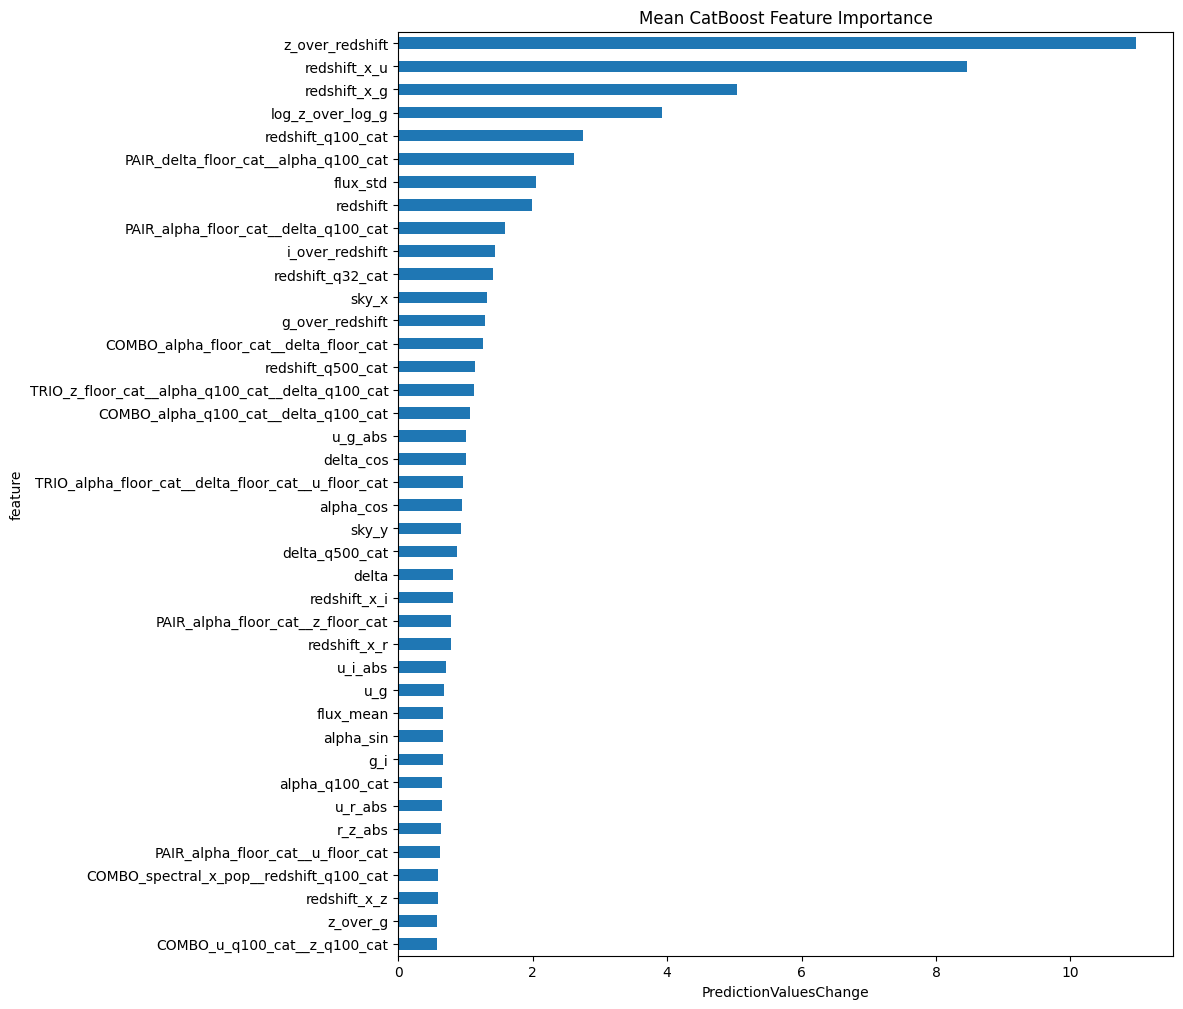

In [9]:
if len(feature_importance):
    fi = (feature_importance
          .groupby('feature', as_index=False)['importance']
          .mean()
          .sort_values('importance', ascending=False)
          .head(40))
    display(fi)
    ax = fi.sort_values('importance').plot.barh(x='feature', y='importance', figsize=(10, 12), legend=False)
    ax.set_title('Mean CatBoost Feature Importance')
    ax.set_xlabel('PredictionValuesChange')
else:
    print('No feature importance was collected.')

## Save Artifacts

In [10]:
test_preds = test_pred_sum.astype('float32')
oof_preds = oof.astype('float32')

np.save(OOF_PATH, oof_preds)
np.save(PRED_PATH, test_preds)

pred_labels = [INT_TO_CLASS[i] for i in np.argmax(test_preds, axis=1)]
if sample is not None and ID_COL in sample.columns:
    submission = sample.copy()
    submission[TARGET] = pred_labels
else:
    submission = pd.DataFrame({ID_COL: test_ids, TARGET: pred_labels})
submission.to_csv(SUB_PATH, index=False)

print('Saved exactly three files:')
print(' ', OOF_PATH, oof_preds.shape)
print(' ', PRED_PATH, test_preds.shape)
print(' ', SUB_PATH, submission.shape)
display(submission.head())

Saved exactly three files:
  train_oof/cat-3_oof.npy (577347, 3)
  test_preds/cat-3_test_preds.npy (247435, 3)
  subs/cat-3_submission.csv (247435, 2)


,id,class
0,577347,GALAXY
1,577348,GALAXY
2,577349,GALAXY
3,577350,STAR
4,577351,GALAXY
